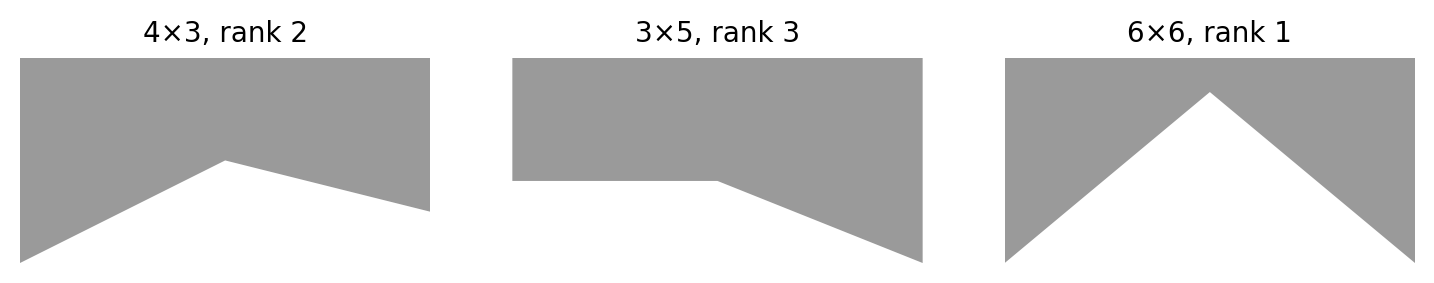

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


def matrix_shape(rows, cols, rank, color="#9a9a9a", edgecolor=None,
                 scale=0.25, ax=None, filename=None):
    """Draw the pentagon diagram for a rows x cols matrix of the given rank.

    Vertices (y increases downward from the top edge):
      top-left (0, 0) -> top-right (w, 0) -> (w, cols) -> (w/2, rank) -> (0, rows)
    where w = 2 * max(rows, cols).

    color     fill color of the polygon (default: a medium grey)
    edgecolor outline color; None means no outline
    scale     inches per unit, so diagrams of different matrices stay comparable
    ax        existing Axes to draw into; if None, a new figure is made
    filename  if given, save with a transparent background
    """
    if min(rows, cols, rank) < 0:
        raise ValueError("rows, cols, and rank must be non-negative")
    if rank > min(rows, cols):
        raise ValueError(f"rank {rank} exceeds min(rows, cols) = {min(rows, cols)}")

    w = 2 * max(rows, cols)
    h = max(rows, cols)
    verts = [(0, 0), (w, 0), (w, -cols), (w / 2, -rank), (0, -rows)]

    if ax is None:
        fig, ax = plt.subplots(figsize=(w * scale, h * scale))
    else:
        fig = ax.figure

    ax.add_patch(Polygon(verts, closed=True, facecolor=color,
                         edgecolor=edgecolor or "none", linewidth=1))
    ax.set_xlim(0, w)
    ax.set_ylim(-h, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    ax.margins(0)

    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", pad_inches=0.02)
    return fig, ax


if __name__ == "__main__":
    fig, axes = plt.subplots(1, 3, figsize=(9, 2.5))
    for ax, (r, c, k) in zip(axes, [(4, 3, 2), (3, 5, 3), (6, 6, 1)]):
        matrix_shape(r, c, k, ax=ax)
        ax.set_title(f"{r}×{c}, rank {k}", fontsize=10)
    fig.savefig("matrix_shape_examples.png", transparent=True,
                bbox_inches="tight", dpi=150)

(<Figure size 100x50 with 1 Axes>, <Axes: >)

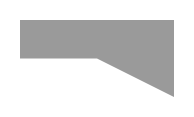

In [2]:
matrix_shape(1, 2, 1)

(<Figure size 100x50 with 1 Axes>, <Axes: >)

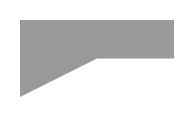

In [3]:
matrix_shape(2, 1, 1)

(<Figure size 100x50 with 1 Axes>, <Axes: >)

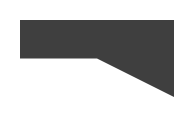

In [7]:
matrix_shape(1, 2, 1, color="#3F3F3F")

(<Figure size 100x50 with 1 Axes>, <Axes: >)

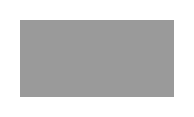

In [16]:
matrix_shape(2, 2, 2)

(<Figure size 100x50 with 1 Axes>, <Axes: >)

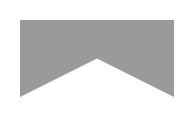

In [17]:
matrix_shape(2, 2, 1)

(<Figure size 200x100 with 1 Axes>, <Axes: >)

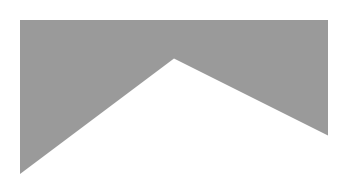

In [45]:
matrix_shape(4, 3, 1)

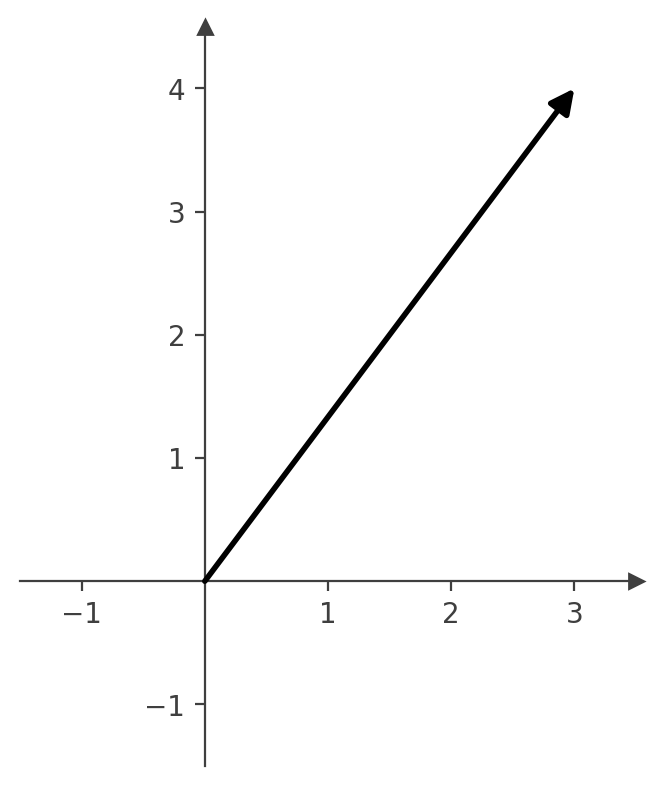

In [9]:
import matplotlib.pyplot as plt


def vector_plot(v=(3, 4), xlim=(-1.5, 3.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """Math-style plot of a vector from the origin, transparent background.

    Axes cross at the origin, ticks/labels on whole numbers only, none at zero.
    scale is inches per unit.
    """
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    # Axes through the origin, math style
    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(axis_color)
    ax.tick_params(colors=axis_color)  # tick marks and labels

    # Arrowheads on the positive ends of the axes
    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(), clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(), clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")

    import math
    xt = [i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0]
    yt = [i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0]
    ax.set_xticks(xt)
    ax.set_yticks(yt)

    # The vector
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")

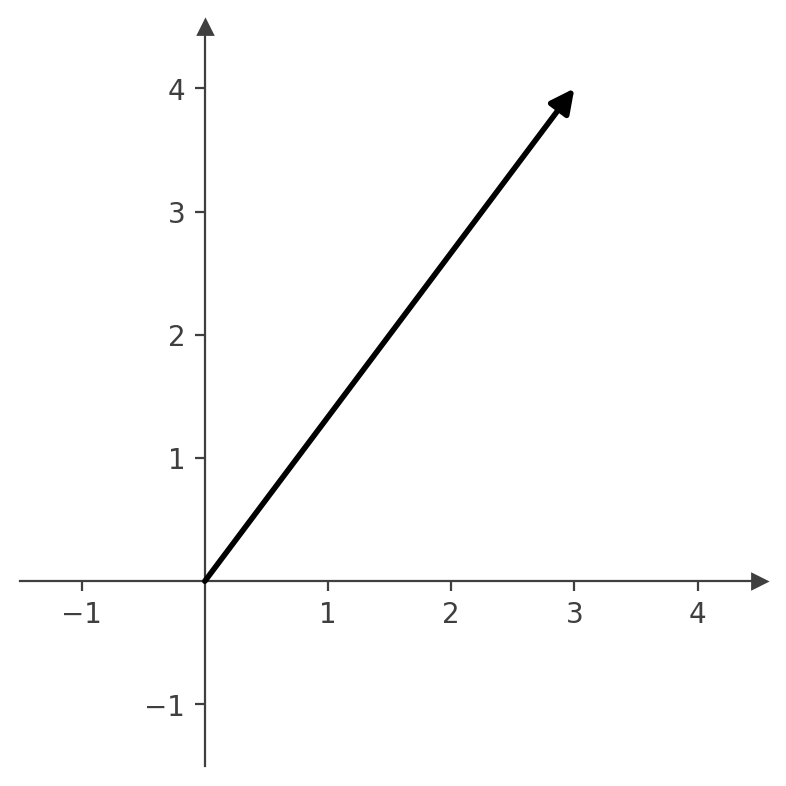

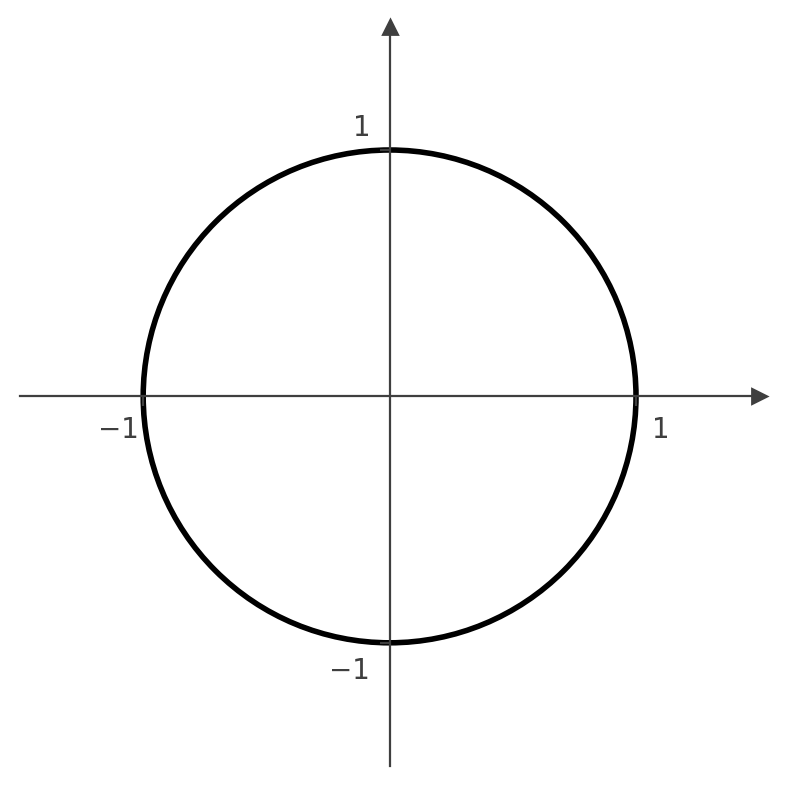

In [10]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit."""
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=axis_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))
    _save(fig, filename)
    return fig, ax


def unit_circle(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    ax.add_patch(Circle((0, 0), 1, fill=False, edgecolor=color, lw=2))

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle(filename="unit_circle.png")

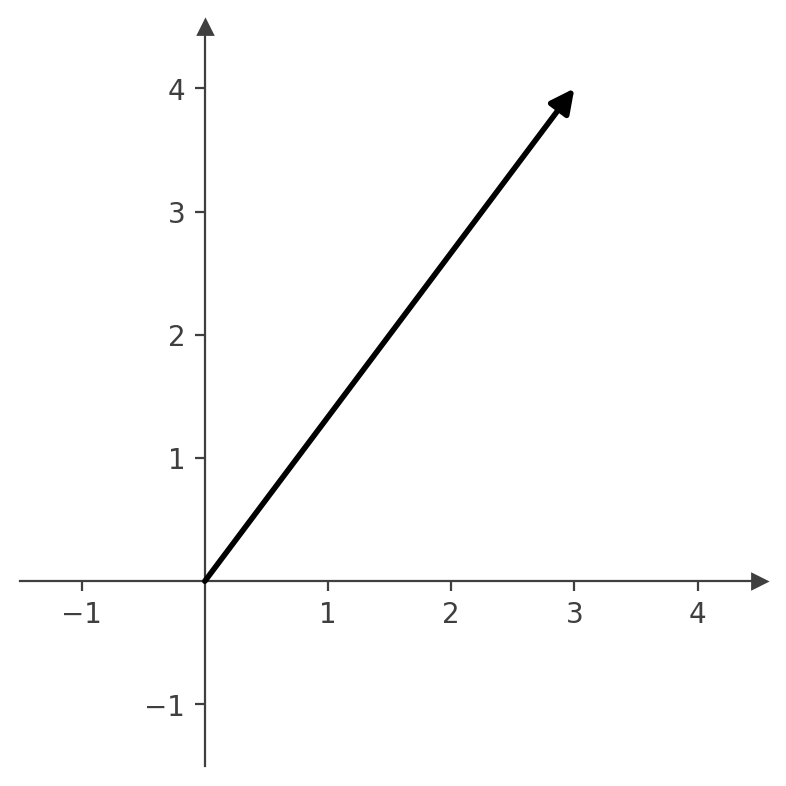

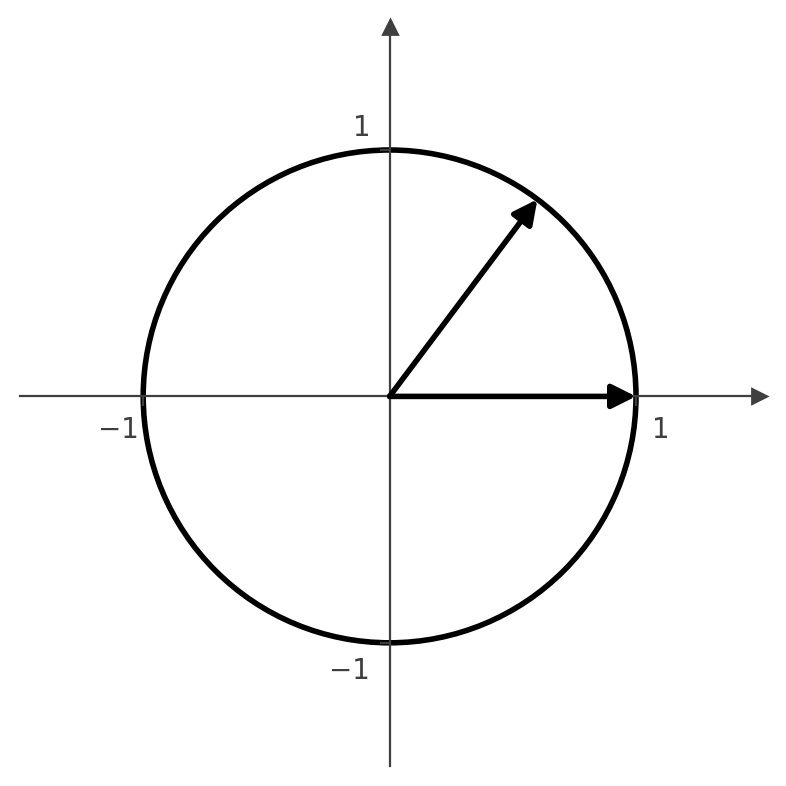

In [11]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit."""
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=axis_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def _arrow(ax, v, color):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    _arrow(ax, v, color)
    _save(fig, filename)
    return fig, ax


def unit_circle(vectors=(), xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin, plus optional vectors
    drawn as arrows from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    ax.add_patch(Circle((0, 0), 1, fill=False, edgecolor=color, lw=2))
    for v in vectors:
        _arrow(ax, v, color)

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle([(1, 0), (3/5, 4/5)], filename="unit_circle.png")

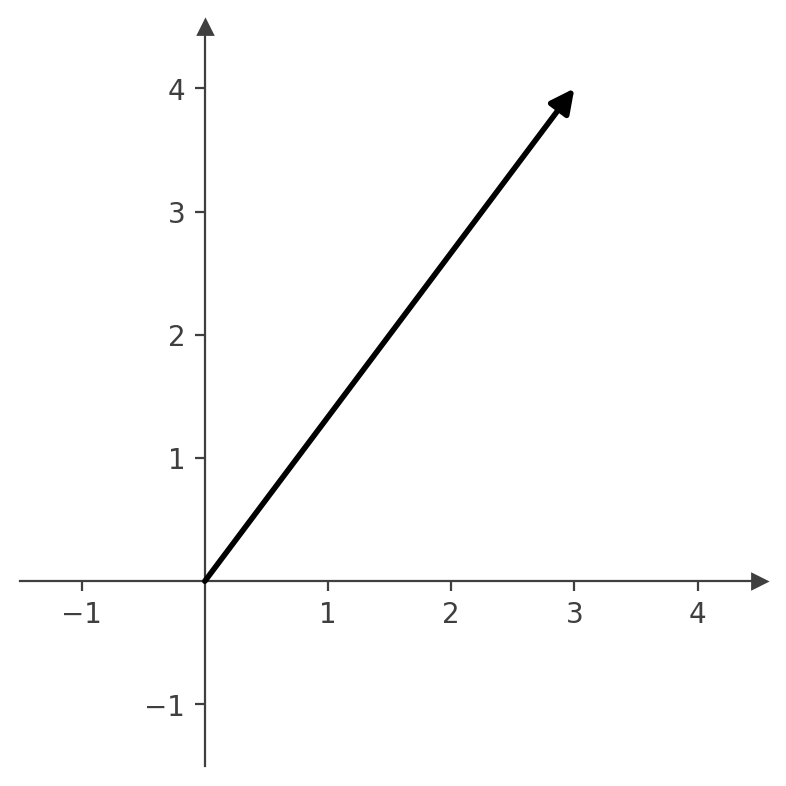

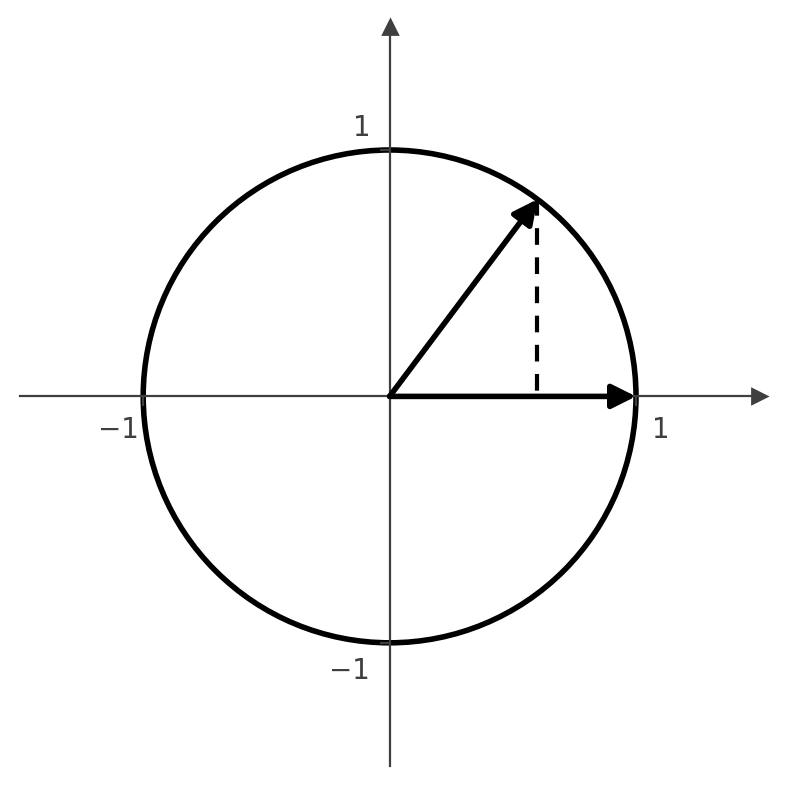

In [12]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit."""
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=axis_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def _arrow(ax, v, color):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    _arrow(ax, v, color)
    _save(fig, filename)
    return fig, ax


def unit_circle(vectors=(), drops=(), xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin, plus optional vectors
    drawn as arrows from the origin. For each point in drops, a dashed
    line runs straight down (or up) to the x-axis."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    ax.add_patch(Circle((0, 0), 1, fill=False, edgecolor=color, lw=2))
    for v in vectors:
        _arrow(ax, v, color)
    for x, y in drops:
        ax.plot([x, x], [y, 0], color=color, lw=1.5, ls=(0, (4, 3)))

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle([(1, 0), (3/5, 4/5)], drops=[(3/5, 4/5)], filename="unit_circle.png")

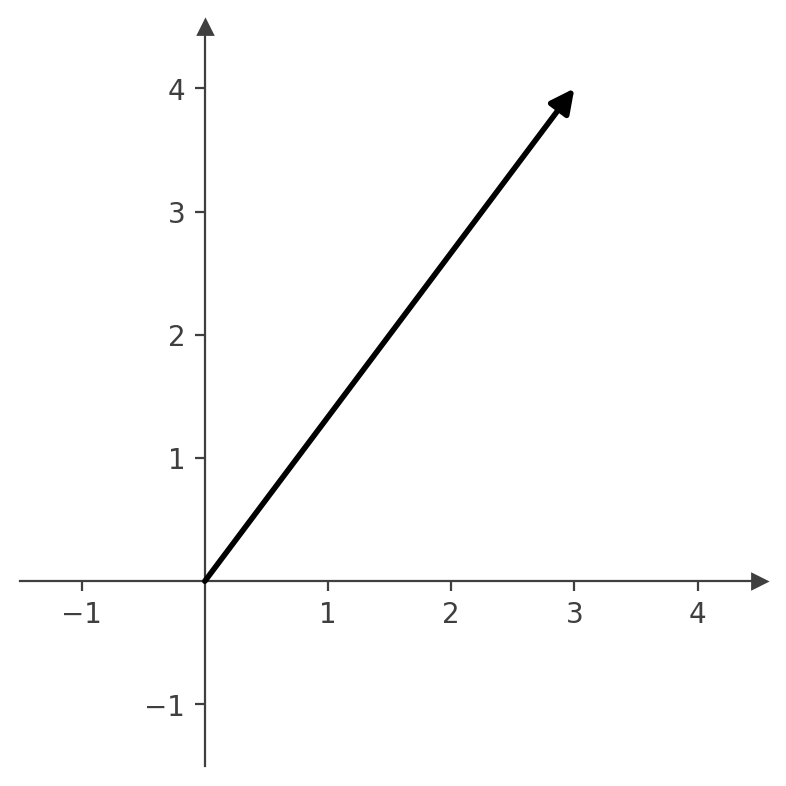

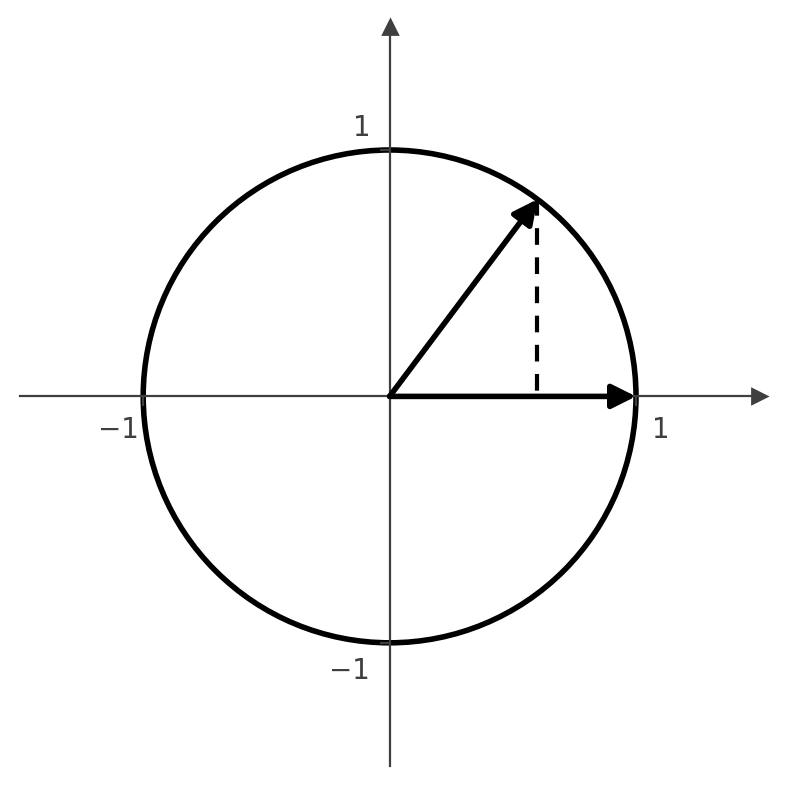

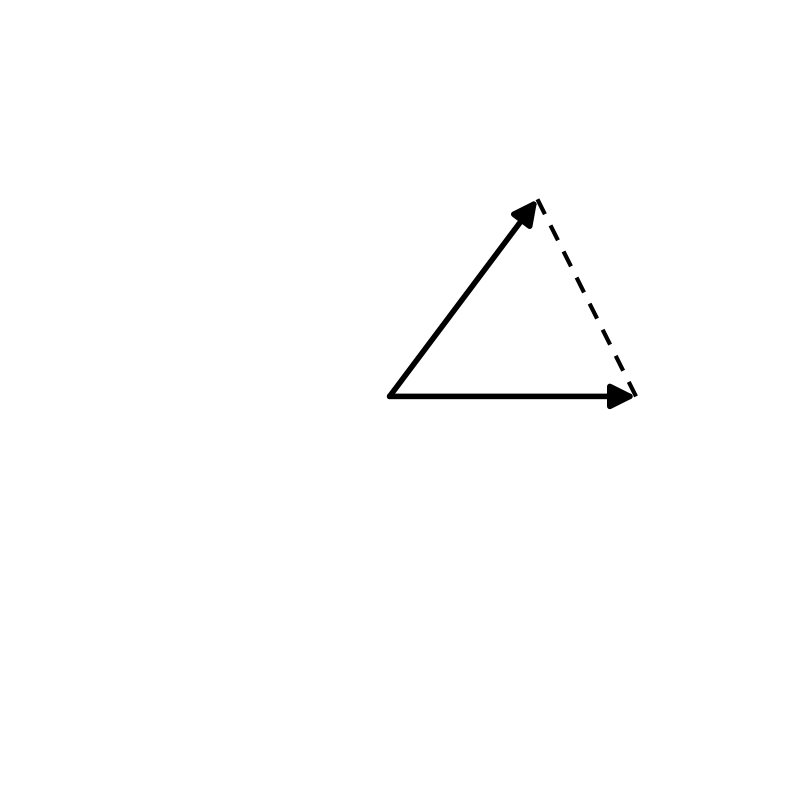

In [13]:
import math

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit."""
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=axis_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def _arrow(ax, v, color):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    _arrow(ax, v, color)
    _save(fig, filename)
    return fig, ax


def unit_circle(vectors=(), drops=(), dashed=(), show_frame=True,
                xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin, plus optional vectors
    drawn as arrows from the origin.

    drops       points; a dashed line runs from each straight to the x-axis
    dashed      pairs of points; a dashed line connects each pair
    show_frame  if False, the axes, labels and circle are made fully
                transparent (not removed), so the image keeps exactly the
                same size and alignment as the framed version and the two
                can be layered.
    """
    frame_axis = axis_color if show_frame else to_rgba(axis_color, 0)
    frame_line = color if show_frame else to_rgba(color, 0)

    fig, ax = math_axes(xlim, ylim, frame_axis, scale)
    ax.add_patch(Circle((0, 0), 1, fill=False, edgecolor=frame_line, lw=2))
    for v in vectors:
        _arrow(ax, v, color)
    dash = dict(color=color, lw=1.5, ls=(0, (4, 3)))
    for x, y in drops:
        ax.plot([x, x], [y, 0], **dash)
    for (x1, y1), (x2, y2) in dashed:
        ax.plot([x1, x2], [y1, y2], **dash)

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle([(1, 0), (3/5, 4/5)], drops=[(3/5, 4/5)], filename="unit_circle.png")
    unit_circle([(1, 0), (3/5, 4/5)], dashed=[((3/5, 4/5), (1, 0))],
                show_frame=False, filename="unit_circle_vectors_only.png")

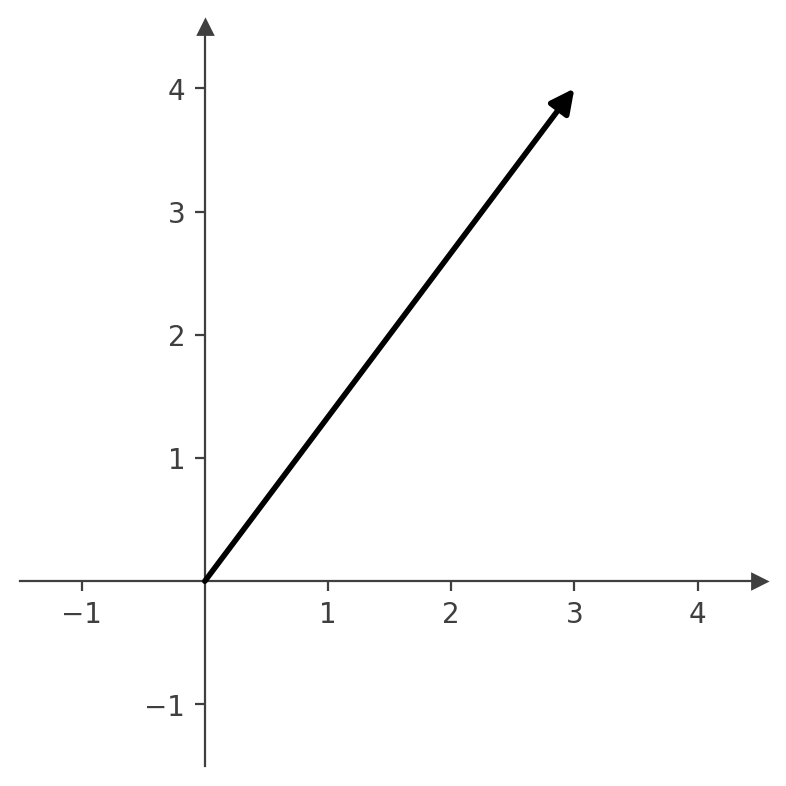

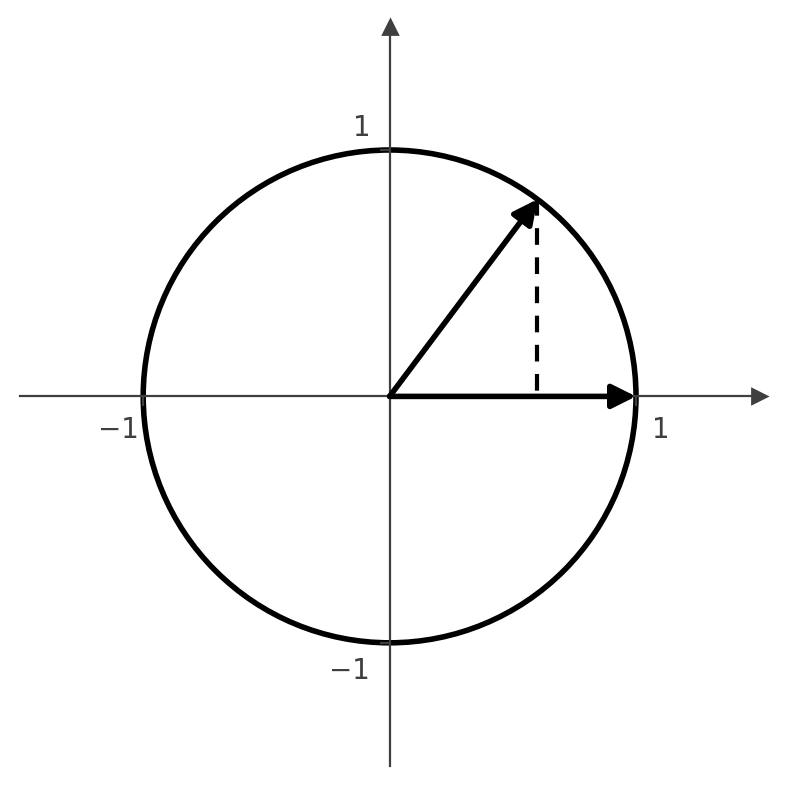

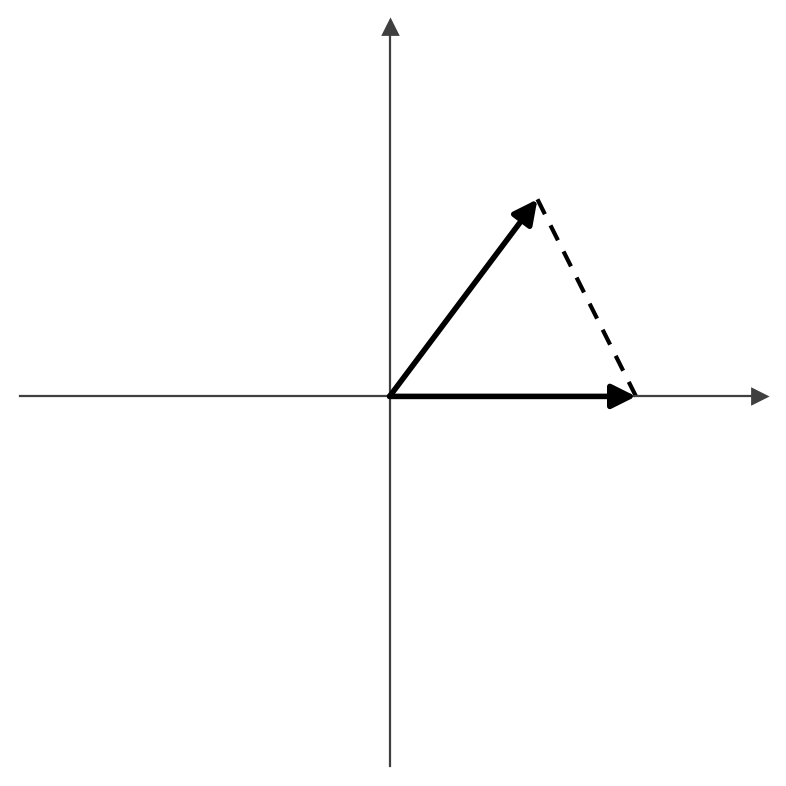

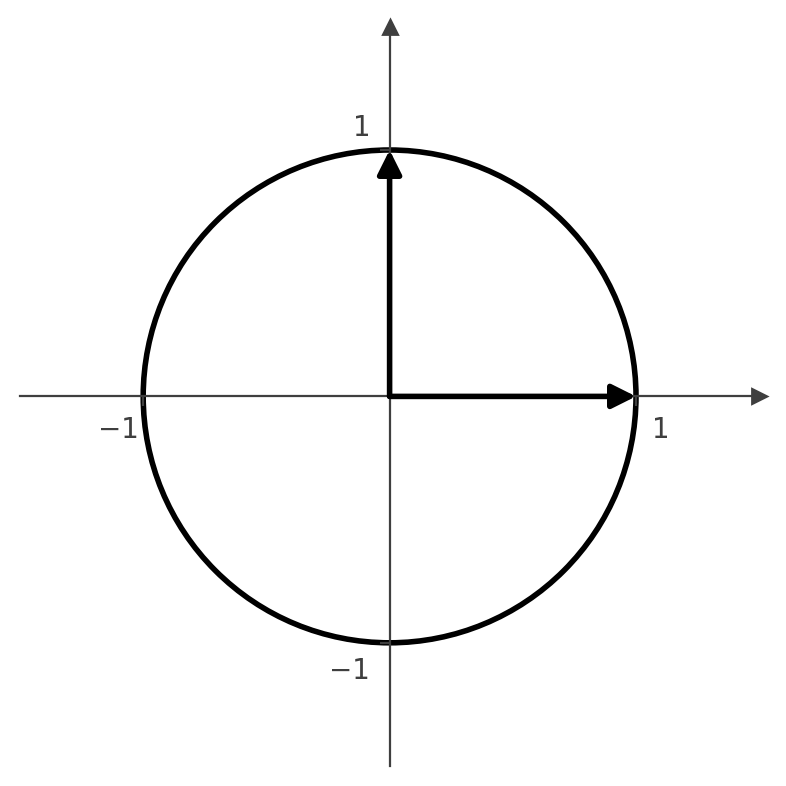

In [14]:
import math

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8, tick_color=None):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit. tick_color (tick marks
    and labels) defaults to axis_color."""
    if tick_color is None:
        tick_color = axis_color
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=tick_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def _arrow(ax, v, color):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    _arrow(ax, v, color)
    _save(fig, filename)
    return fig, ax


def unit_circle(vectors=(), drops=(), dashed=(),
                show_axes=True, show_ticks=True, show_circle=True,
                xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin, plus optional vectors
    drawn as arrows from the origin.

    drops       points; a dashed line runs from each straight to the x-axis
    dashed      pairs of points; a dashed line connects each pair
    show_axes, show_ticks, show_circle
                hidden parts are made fully transparent rather than removed,
                so every variant has exactly the same size and alignment and
                they can be layered. show_ticks covers tick marks and labels.
    """
    hide = lambda c, shown: c if shown else to_rgba(c, 0)

    fig, ax = math_axes(xlim, ylim, hide(axis_color, show_axes), scale,
                        tick_color=hide(axis_color, show_axes and show_ticks))
    ax.add_patch(Circle((0, 0), 1, fill=False,
                        edgecolor=hide(color, show_circle), lw=2))
    for v in vectors:
        _arrow(ax, v, color)
    dash = dict(color=color, lw=1.5, ls=(0, (4, 3)))
    for x, y in drops:
        ax.plot([x, x], [y, 0], **dash)
    for (x1, y1), (x2, y2) in dashed:
        ax.plot([x1, x2], [y1, y2], **dash)

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle([(1, 0), (3/5, 4/5)], drops=[(3/5, 4/5)], filename="unit_circle.png")
    unit_circle([(1, 0), (3/5, 4/5)], dashed=[((3/5, 4/5), (1, 0))],
                show_ticks=False, show_circle=False, filename="unit_circle_vectors_only.png")
    unit_circle([(1, 0), (0, 1)], filename="unit_circle_basis.png")

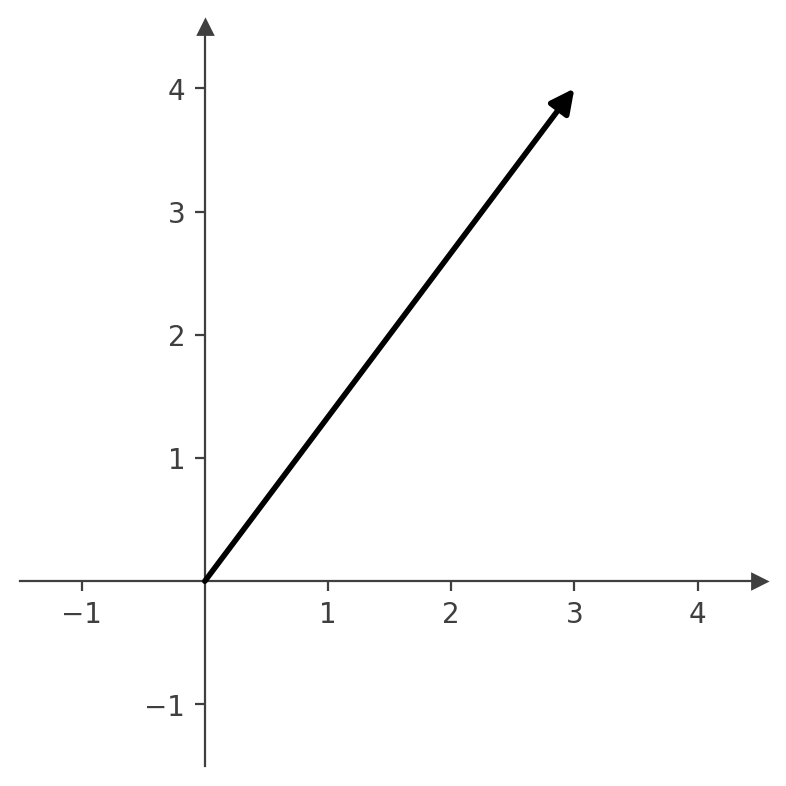

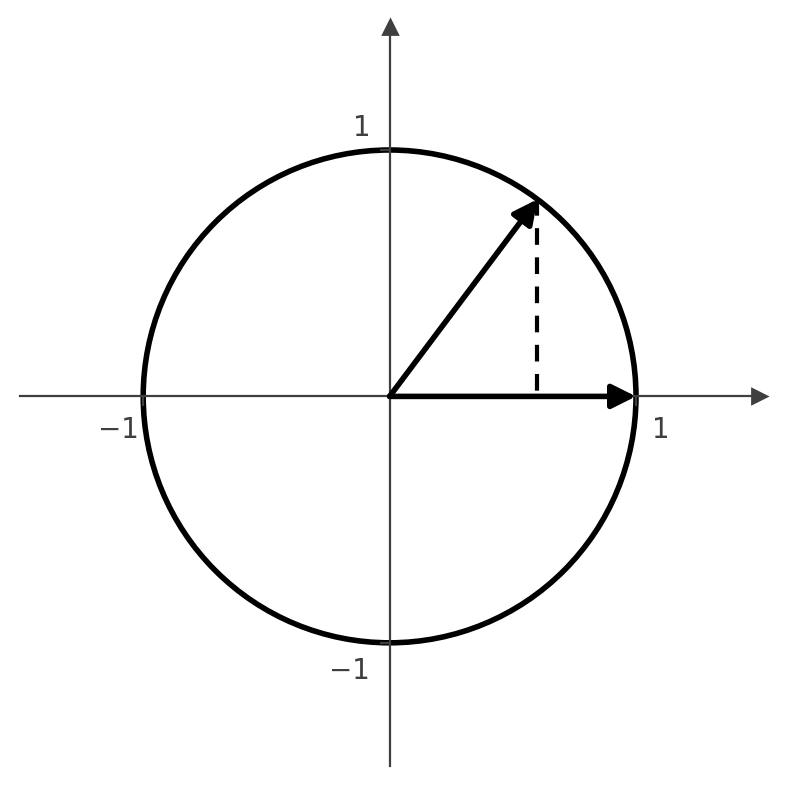

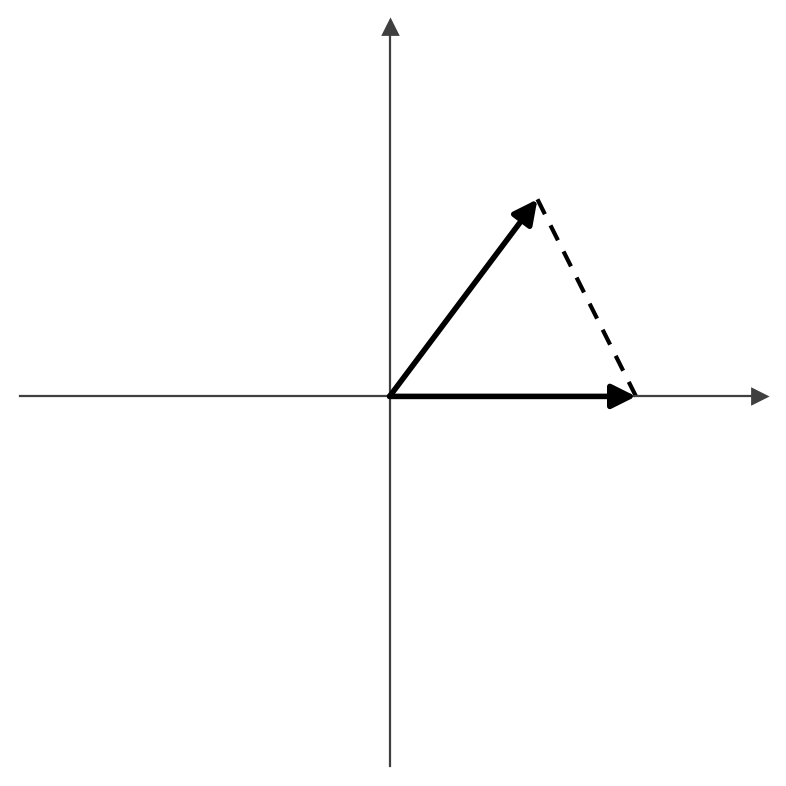

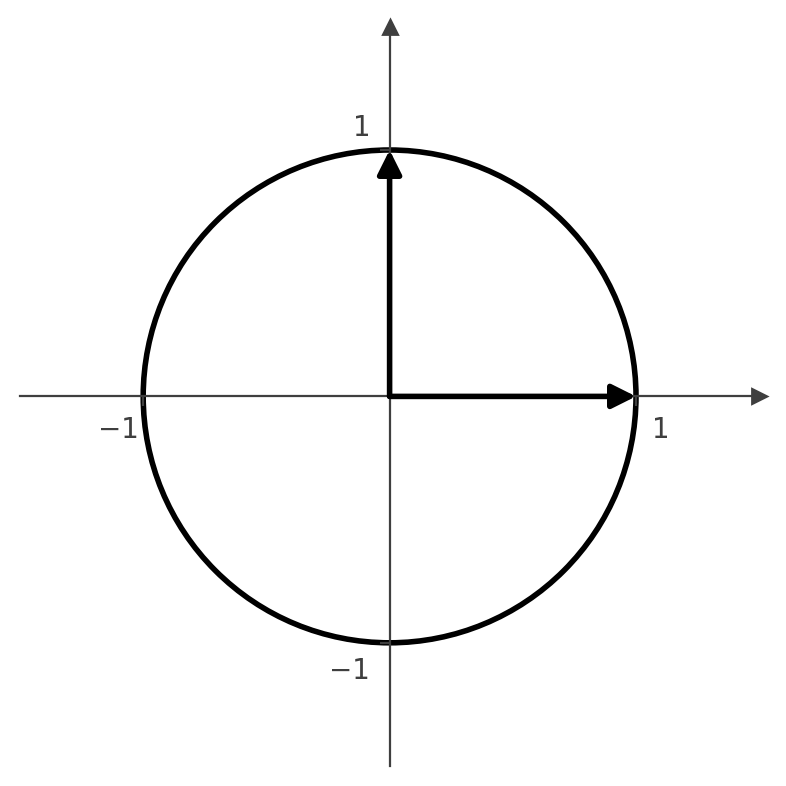

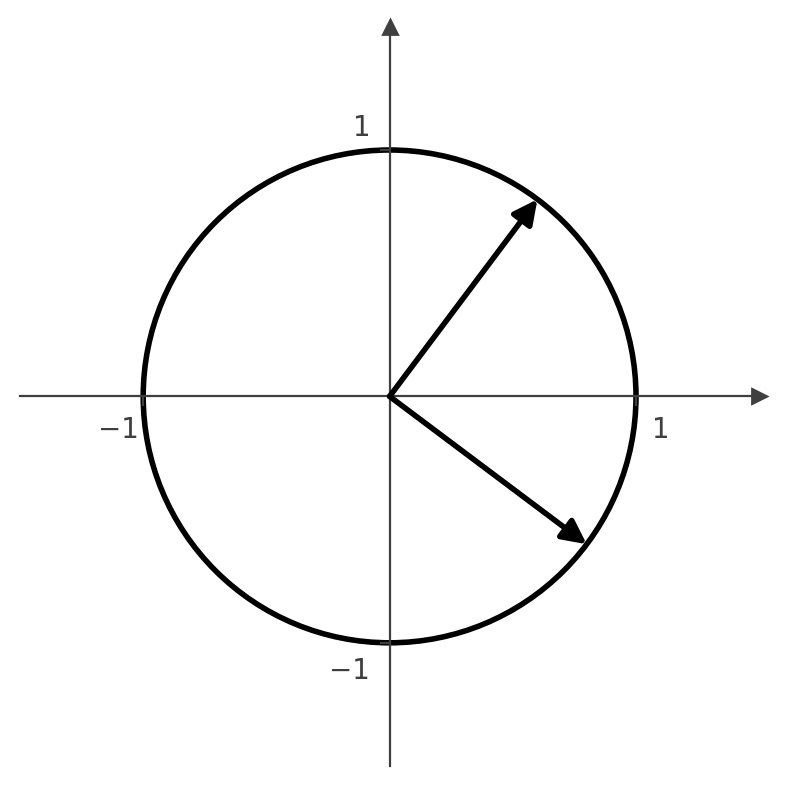

In [15]:
import math

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8, tick_color=None):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit. tick_color (tick marks
    and labels) defaults to axis_color."""
    if tick_color is None:
        tick_color = axis_color
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=tick_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def _arrow(ax, v, color):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0))


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    _arrow(ax, v, color)
    _save(fig, filename)
    return fig, ax


def unit_circle(vectors=(), drops=(), dashed=(),
                show_axes=True, show_ticks=True, show_circle=True,
                xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin, plus optional vectors
    drawn as arrows from the origin.

    drops       points; a dashed line runs from each straight to the x-axis
    dashed      pairs of points; a dashed line connects each pair
    show_axes, show_ticks, show_circle
                hidden parts are made fully transparent rather than removed,
                so every variant has exactly the same size and alignment and
                they can be layered. show_ticks covers tick marks and labels.
    """
    hide = lambda c, shown: c if shown else to_rgba(c, 0)

    fig, ax = math_axes(xlim, ylim, hide(axis_color, show_axes), scale,
                        tick_color=hide(axis_color, show_axes and show_ticks))
    ax.add_patch(Circle((0, 0), 1, fill=False,
                        edgecolor=hide(color, show_circle), lw=2))
    for v in vectors:
        _arrow(ax, v, color)
    dash = dict(color=color, lw=1.5, ls=(0, (4, 3)))
    for x, y in drops:
        ax.plot([x, x], [y, 0], **dash)
    for (x1, y1), (x2, y2) in dashed:
        ax.plot([x1, x2], [y1, y2], **dash)

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle([(1, 0), (3/5, 4/5)], drops=[(3/5, 4/5)], filename="unit_circle.png")
    unit_circle([(1, 0), (3/5, 4/5)], dashed=[((3/5, 4/5), (1, 0))],
                show_ticks=False, show_circle=False, filename="unit_circle_vectors_only.png")
    unit_circle([(1, 0), (0, 1)], filename="unit_circle_basis.png")
    unit_circle([(3/5, 4/5), (4/5, -3/5)], filename="unit_circle_3_4.png")

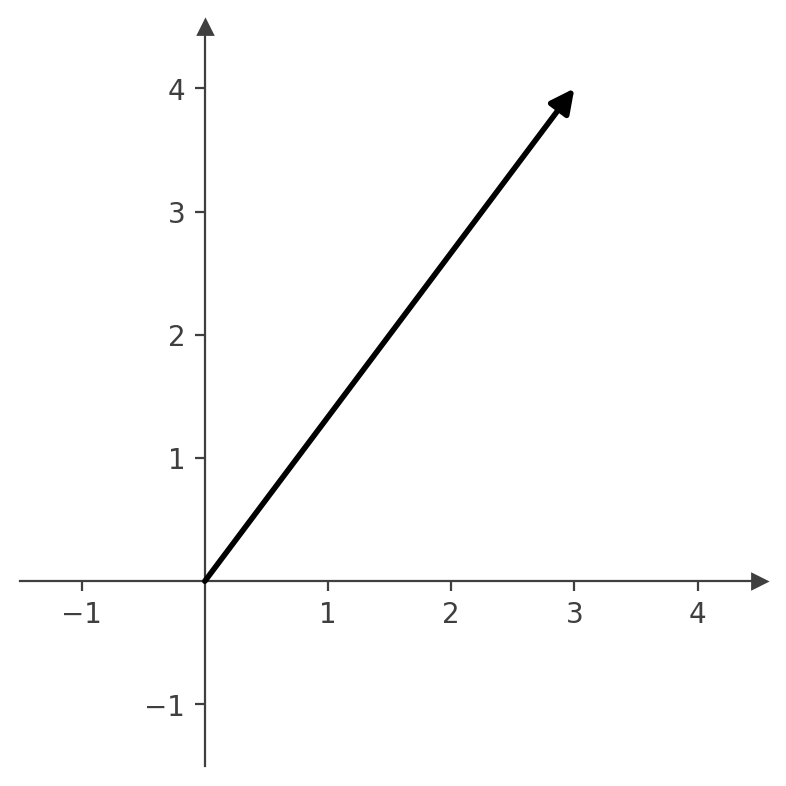

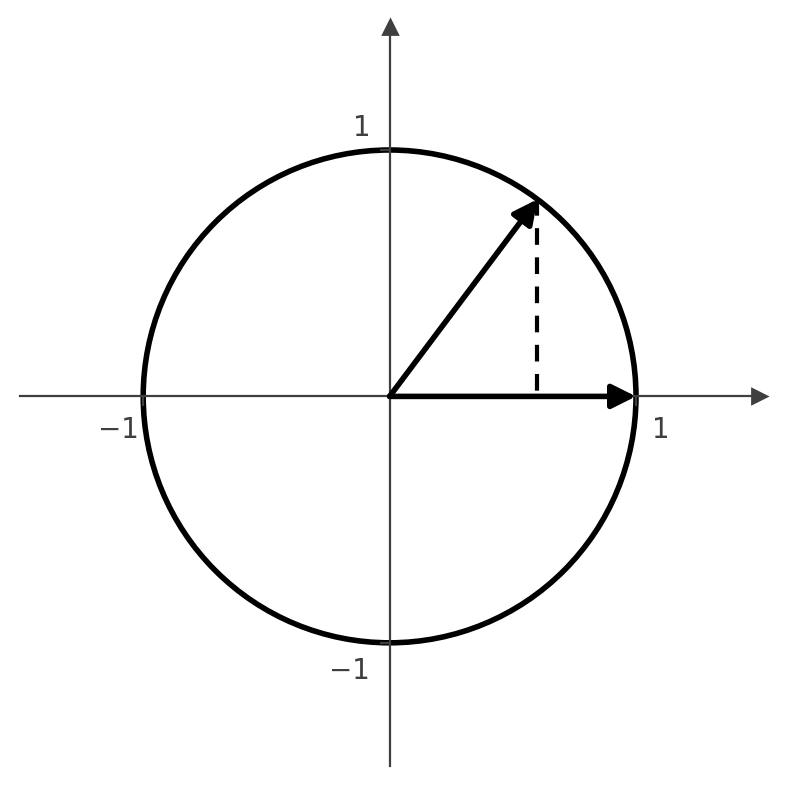

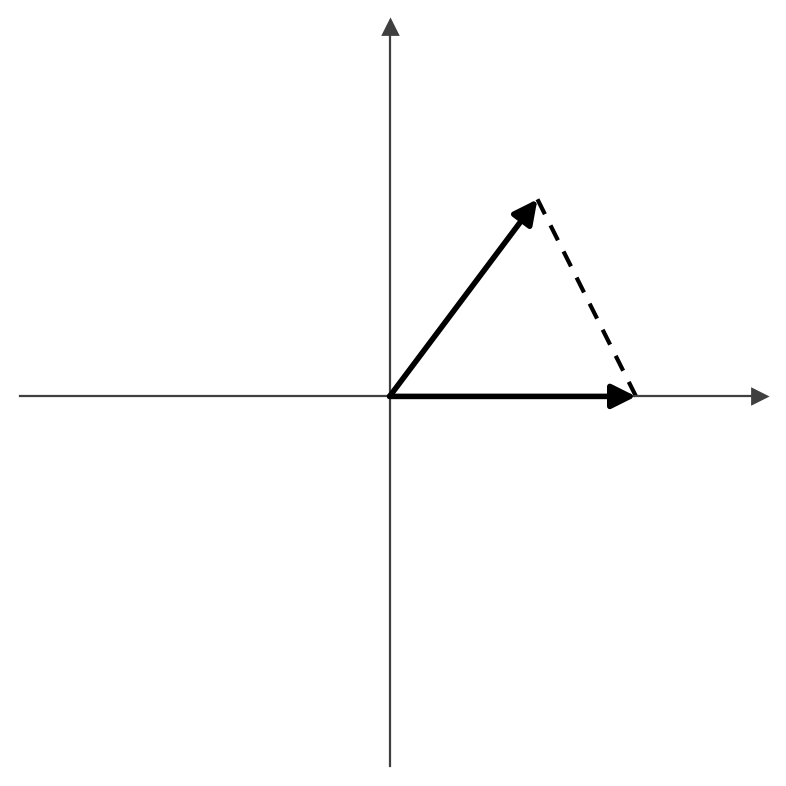

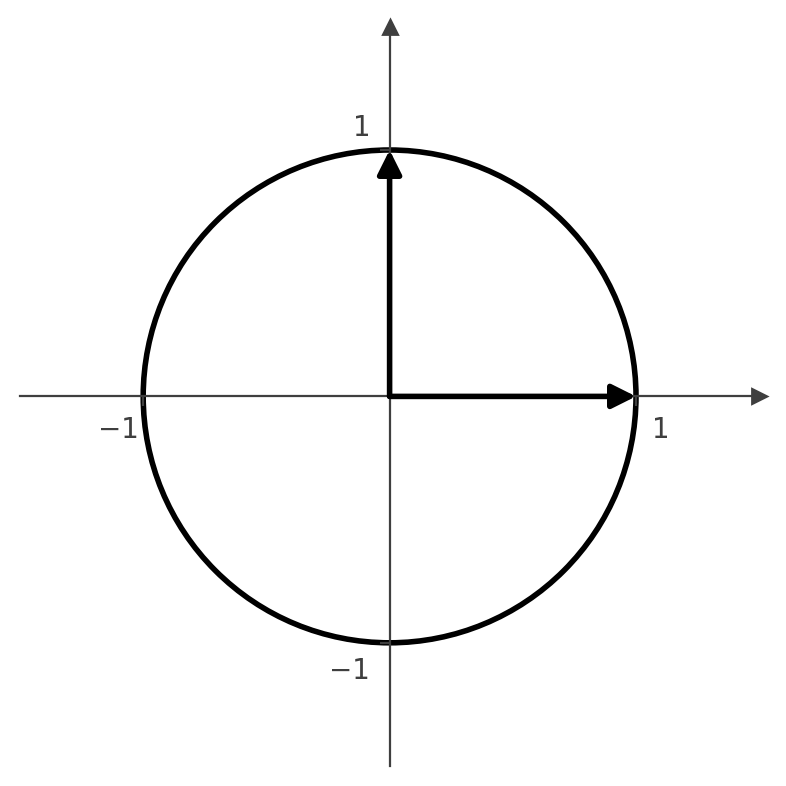

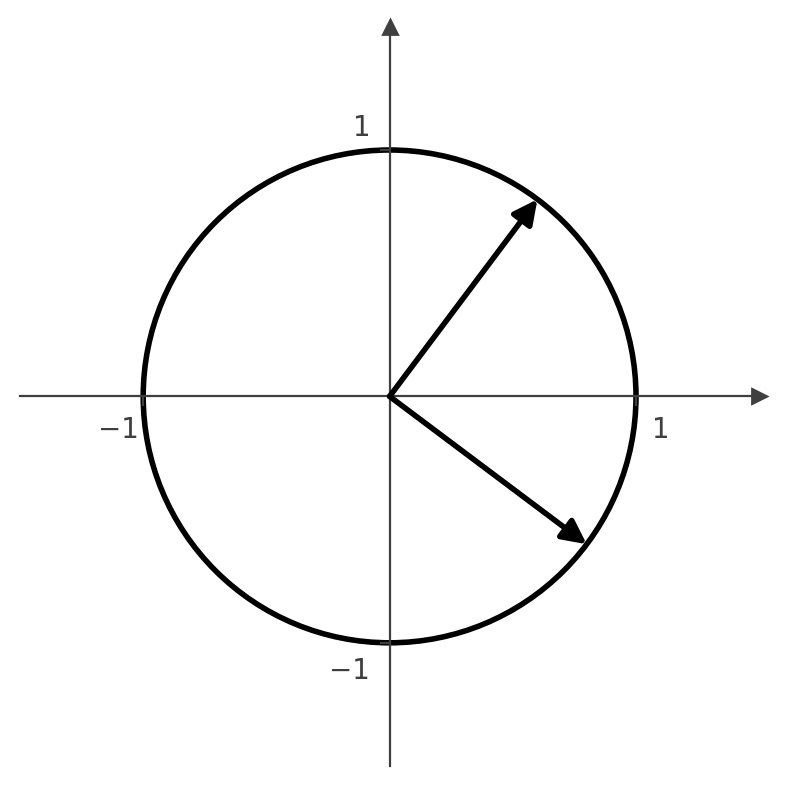

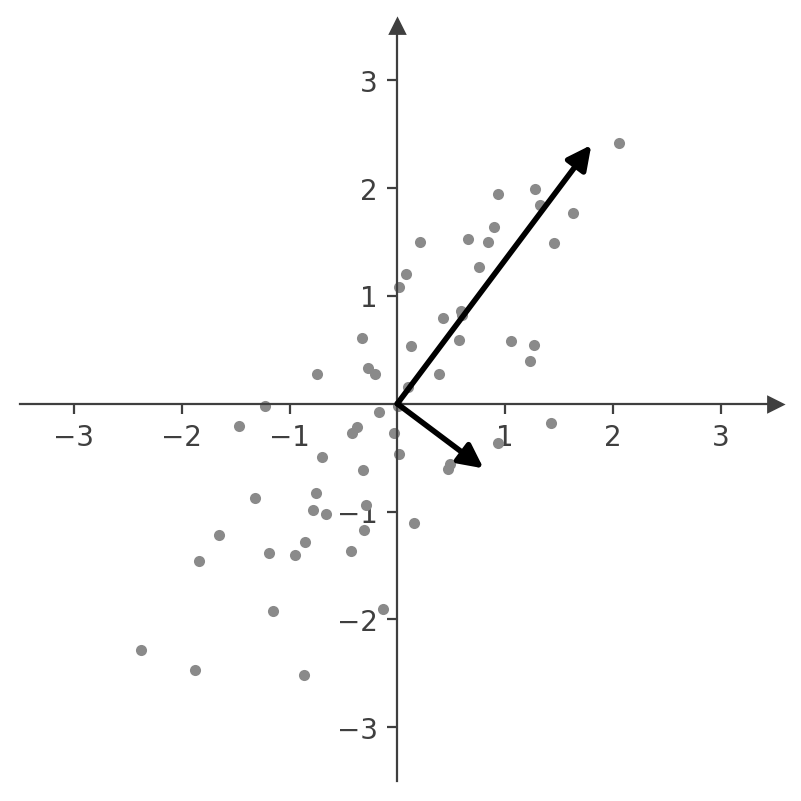

In [18]:
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
from matplotlib.patches import Circle
from matplotlib.transforms import ScaledTranslation


def math_axes(xlim, ylim, axis_color="#3F3F3F", scale=0.8, tick_color=None):
    """Math-style axes: cross at the origin, arrowheads on the positive ends,
    ticks/labels on whole numbers only (none at zero), equal aspect,
    transparent background. scale is inches per unit. tick_color (tick marks
    and labels) defaults to axis_color."""
    if tick_color is None:
        tick_color = axis_color
    w, h = xlim[1] - xlim[0], ylim[1] - ylim[0]
    fig, ax = plt.subplots(figsize=(w * scale, h * scale))

    for side in ("left", "bottom"):
        ax.spines[side].set_position("zero")
        ax.spines[side].set_color(axis_color)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=tick_color)  # tick marks and labels

    ax.plot(1, 0, ">", color=axis_color, transform=ax.get_yaxis_transform(),
            clip_on=False, ms=5)
    ax.plot(0, 1, "^", color=axis_color, transform=ax.get_xaxis_transform(),
            clip_on=False, ms=5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([i for i in range(math.ceil(xlim[0]), math.floor(xlim[1]) + 1) if i != 0])
    ax.set_yticks([i for i in range(math.ceil(ylim[0]), math.floor(ylim[1]) + 1) if i != 0])

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    return fig, ax


def _save(fig, filename):
    if filename:
        fig.savefig(filename, transparent=True, bbox_inches="tight", dpi=150)


def _arrow(ax, v, color, start=(0, 0)):
    ax.annotate("", xy=(start[0] + v[0], start[1] + v[1]), xytext=start,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0),
                zorder=3)


def vector_plot(v=(3, 4), xlim=(-1.5, 4.5), ylim=(-1.5, 4.5),
                color="black", axis_color="#3F3F3F", scale=0.8, filename=None):
    """A vector drawn as an arrow from the origin."""
    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    _arrow(ax, v, color)
    _save(fig, filename)
    return fig, ax


def unit_circle(vectors=(), drops=(), dashed=(),
                show_axes=True, show_ticks=True, show_circle=True,
                xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                color="black", axis_color="#3F3F3F", scale=1.6, filename=None):
    """The unit circle centered at the origin, plus optional vectors
    drawn as arrows from the origin.

    drops       points; a dashed line runs from each straight to the x-axis
    dashed      pairs of points; a dashed line connects each pair
    show_axes, show_ticks, show_circle
                hidden parts are made fully transparent rather than removed,
                so every variant has exactly the same size and alignment and
                they can be layered. show_ticks covers tick marks and labels.
    """
    hide = lambda c, shown: c if shown else to_rgba(c, 0)

    fig, ax = math_axes(xlim, ylim, hide(axis_color, show_axes), scale,
                        tick_color=hide(axis_color, show_axes and show_ticks))
    ax.add_patch(Circle((0, 0), 1, fill=False,
                        edgecolor=hide(color, show_circle), lw=2))
    for v in vectors:
        _arrow(ax, v, color)
    dash = dict(color=color, lw=1.5, ls=(0, (4, 3)))
    for x, y in drops:
        ax.plot([x, x], [y, 0], **dash)
    for (x1, y1), (x2, y2) in dashed:
        ax.plot([x1, x2], [y1, y2], **dash)

    # The circle crosses the axes exactly at the ±1 ticks, so nudge those
    # labels outward (away from the origin) so the curve doesn't run through them.
    nudge = 9 / 72  # inches
    fig.canvas.draw()  # tick labels exist after a draw
    for lab in ax.get_xticklabels():
        x = lab.get_position()[0]
        if abs(x) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                math.copysign(nudge, x), 0, fig.dpi_scale_trans))
    for lab in ax.get_yticklabels():
        y = lab.get_position()[1]
        if abs(y) == 1:
            lab.set_transform(lab.get_transform() + ScaledTranslation(
                0, math.copysign(nudge, y), fig.dpi_scale_trans))
    _save(fig, filename)
    return fig, ax


def demo_cloud(n=60, directions=((3, 4), (4, -3)), sds=(1.5, 0.5), seed=8):
    """n random 2-D points, centered at the origin, whose principal directions
    are exactly `directions` and whose standard deviations along them are
    exactly `sds`. (The raw Gaussian sample is whitened first, so the sample
    PCA matches the requested shape exactly rather than approximately.)"""
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((n, 2))
    z -= z.mean(axis=0)
    # whiten: sample covariance becomes exactly the identity
    evals, evecs = np.linalg.eigh(np.cov(z, rowvar=False))
    z = z @ evecs @ np.diag(1 / np.sqrt(evals)) @ evecs.T
    d = np.array(directions, dtype=float)
    d /= np.linalg.norm(d, axis=1, keepdims=True)
    return z @ np.diag(sds) @ d


def pca_plot(points=None, xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), length=2,
             color="black", point_color="#8a8a8a", point_size=16,
             axis_color="#3F3F3F", scale=0.7, filename=None):
    """Scatter of 2-D points with the principal component directions drawn
    as arrows from the mean.

    Each arrow's length is its singular value from the SVD of the centered
    data divided by sqrt(n - 1), i.e. the standard deviation of the data
    along that direction (which keeps lengths comparable across different n),
    times `length`. The default, length=2, gives 2-SD arrows that reach about
    the edge of the bulk of the cloud. length="sd" is the same as 1;
    length="raw" uses the singular value itself.
    """
    if points is None:
        points = demo_cloud()
    X = np.asarray(points, dtype=float)
    mean = X.mean(axis=0)
    _, s, Vt = np.linalg.svd(X - mean, full_matrices=False)

    if length == "raw":
        lengths = s
    else:
        k = 1 if length == "sd" else float(length)
        lengths = k * s / math.sqrt(len(X) - 1)

    fig, ax = math_axes(xlim, ylim, axis_color, scale)
    ax.scatter(X[:, 0], X[:, 1], s=point_size, color=point_color,
               linewidths=0, zorder=2)
    for L, v in zip(lengths, Vt):
        if v[0] < 0 or (v[0] == 0 and v[1] < 0):  # SVD signs are arbitrary
            v = -v
        _arrow(ax, L * v, color, start=mean)
    _save(fig, filename)
    return fig, ax


if __name__ == "__main__":
    vector_plot((3, 4), filename="vector_3_4.png")
    unit_circle([(1, 0), (3/5, 4/5)], drops=[(3/5, 4/5)], filename="unit_circle.png")
    unit_circle([(1, 0), (3/5, 4/5)], dashed=[((3/5, 4/5), (1, 0))],
                show_ticks=False, show_circle=False, filename="unit_circle_vectors_only.png")
    unit_circle([(1, 0), (0, 1)], filename="unit_circle_basis.png")
    unit_circle([(3/5, 4/5), (4/5, -3/5)], filename="unit_circle_3_4.png")
    pca_plot(filename="pca.png")

In [19]:
A = np.array([[4, 3, 2],
              [5, 3, 1],
              [1, 3, 5],
              [2, 3, 4]])

In [20]:
A - 3

array([[ 1,  0, -1],
       [ 2,  0, -2],
       [-2,  0,  2],
       [-1,  0,  1]])

In [22]:
(A - 3).T @ (A - 3)

array([[ 10,   0, -10],
       [  0,   0,   0],
       [-10,   0,  10]])

In [24]:
(A - 3) @ (A - 3).T

array([[ 2,  4, -4, -2],
       [ 4,  8, -8, -4],
       [-4, -8,  8,  4],
       [-2, -4,  4,  2]])

In [42]:
centered = A - 3
centered.T @ centered

array([[ 10,   0, -10],
       [  0,   0,   0],
       [-10,   0,  10]])

In [44]:
np.linalg.svd(centered)

SVDResult(U=array([[-0.31622777,  0.9486833 ,  0.        ,  0.        ],
       [-0.63245553, -0.21081851,  0.66666667,  0.33333333],
       [ 0.63245553,  0.21081851,  0.73333333, -0.13333333],
       [ 0.31622777,  0.10540926, -0.13333333,  0.93333333]]), S=array([4.47213595e+00, 4.88791056e-16, 0.00000000e+00]), Vh=array([[-0.70710678,  0.        ,  0.70710678],
       [ 0.70710678,  0.        ,  0.70710678],
       [ 0.        , -1.        ,  0.        ]]))

In [43]:
np.cov(A.T)

array([[ 3.33333333,  0.        , -3.33333333],
       [ 0.        ,  0.        ,  0.        ],
       [-3.33333333,  0.        ,  3.33333333]])

In [46]:
A

array([[4, 3, 2],
       [5, 3, 1],
       [1, 3, 5],
       [2, 3, 4]])

In [23]:
np.cov(A)

array([[ 1.,  2., -2., -1.],
       [ 2.,  4., -4., -2.],
       [-2., -4.,  4.,  2.],
       [-1., -2.,  2.,  1.]])

In [40]:
rows = A - 3
rows = rows / np.linalg.norm(rows, axis=1, keepdims=True)
rows @ rows.T

array([[ 1.,  1., -1., -1.],
       [ 1.,  1., -1., -1.],
       [-1., -1.,  1.,  1.],
       [-1., -1.,  1.,  1.]])

In [41]:
rows

array([[ 0.70710678,  0.        , -0.70710678],
       [ 0.70710678,  0.        , -0.70710678],
       [-0.70710678,  0.        ,  0.70710678],
       [-0.70710678,  0.        ,  0.70710678]])

In [39]:
cols = A - 3
cols = cols / np.linalg.norm(cols, axis=0, keepdims=True)
cols[np.isnan(cols)] = 0
cols.T @ cols

/var/folders/3n/v6kbxqb94b92ys1nm0gbhrvm0000gn/T/ipykernel_45921/3148042760.py:2: RuntimeWarning: invalid value encountered in divide
  cols = cols / np.linalg.norm(cols, axis=0, keepdims=True)


array([[ 1.,  0., -1.],
       [ 0.,  0.,  0.],
       [-1.,  0.,  1.]])

In [61]:
x = np.array([[1, 0]]).T
A = np.array([[1, 1],
              [1, 0]])
result = np.linalg.eig(A)

In [65]:
L = np.diag(result.eigenvalues)
X = result.eigenvectors

array([[ 0.85065081, -0.52573111],
       [ 0.52573111,  0.85065081]])

In [76]:
for i in range(1, 10):
    print(X @ L**i @ X.T @ x)

[[1.]
 [1.]]
[[2.]
 [1.]]
[[3.]
 [2.]]
[[5.]
 [3.]]
[[8.]
 [5.]]
[[13.]
 [ 8.]]
[[21.]
 [13.]]
[[34.]
 [21.]]
[[55.]
 [34.]]


In [59]:
np.linalg.matrix_power(A, 5) @ x

array([[8],
       [5]])

In [60]:
np.linalg.eig(A)

EigResult(eigenvalues=array([ 1.61803399, -0.61803399]), eigenvectors=array([[ 0.85065081, -0.52573111],
       [ 0.52573111,  0.85065081]]))